Part 1: Data cleaning

In [33]:
import pandas as pd
import numpy as np

# 1. Load data (Dùng read_excel cho file .xlsx)
df = pd.read_excel(r'C:\Users\Admin\Desktop\Survival analysis\Telco_customer_churn.xlsx')
df.columns = df.columns.str.replace(' ', '')
df.columns = df.columns.str.strip().str.replace(' ', '').str.replace('_', '')
tenure_col = next((col for col in df.columns if 'tenure' in col.lower()), None)
churn_col = next((col for col in df.columns if 'churn' in col.lower() and 'reason' not in col.lower() and 'score' not in col.lower()), None)
df = df.rename(columns={tenure_col: 'tenure', churn_col: 'Churn'})
df

,CustomerID,Count,Country,State,City,ZipCode,LatLong,Latitude,Longitude,Gender,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnValue,ChurnScore,CLTV,ChurnReason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [34]:
# --- DATA CLEANING ---

# 2. Remove Duplicates
df = df.drop_duplicates()

# 3. Handle Missing Values
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges']) 
# Điền 0 cho TotalCharges (chưa đóng phí tháng nào)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 4. Handle Outliers (IQR)
# Áp dụng trên cột MonthlyCharges (Phí hàng tháng)
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Capping
df['MonthlyCharges'] = np.where(df['MonthlyCharges'] > upper_bound, upper_bound, df['MonthlyCharges'])
df['MonthlyCharges'] = np.where(df['MonthlyCharges'] < lower_bound, lower_bound, df['MonthlyCharges'])

# 5. Chuyển đổi biến mục tiêu cho Survival Analysis
df['Churn'] = np.where(df['Churn'].astype(str).str.strip().str.lower() == 'yes', 1, 0)
T = df['tenure'] 
E = df['Churn'] 
print("Kiểm tra lại cột Churn sau khi ép kiểu:\n", E.value_counts())

Kiểm tra lại cột Churn sau khi ép kiểu:
 Churn
0    5174
1    1869
Name: count, dtype: int64


Part 2: Univariate Analysis - Overall Survival Curve Estimation

In [35]:
from lifelines import KaplanMeierFitter, CoxPHFitter
import matplotlib.pyplot as plt

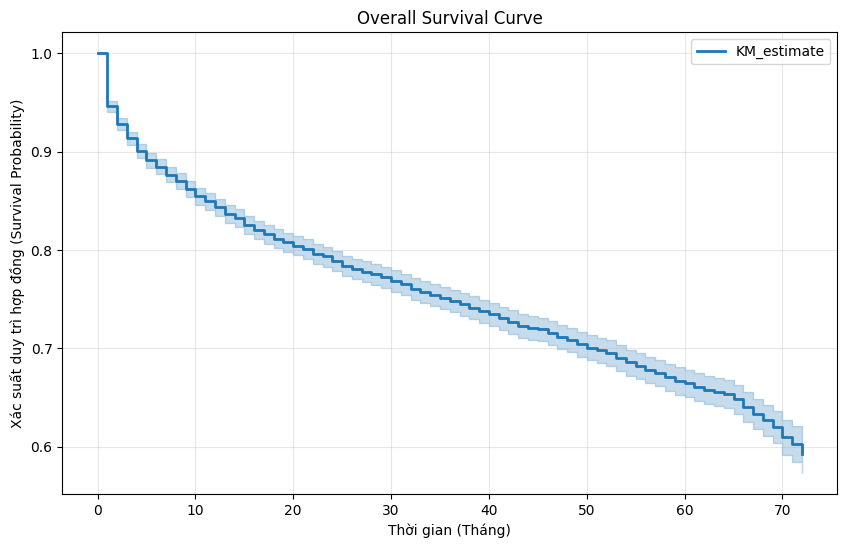

In [36]:
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E)

plt.figure(figsize=(10, 6))
kmf.plot_survival_function(color='#1f77b4', linewidth=2)
plt.title('Overall Survival Curve')
plt.ylabel('Xác suất duy trì hợp đồng (Survival Probability)')
plt.xlabel('Thời gian (Tháng)')
plt.grid(True, alpha=0.3)
plt.show()

Part 3: Stratified Survival Analysis - Risk Comparison by Contract Type

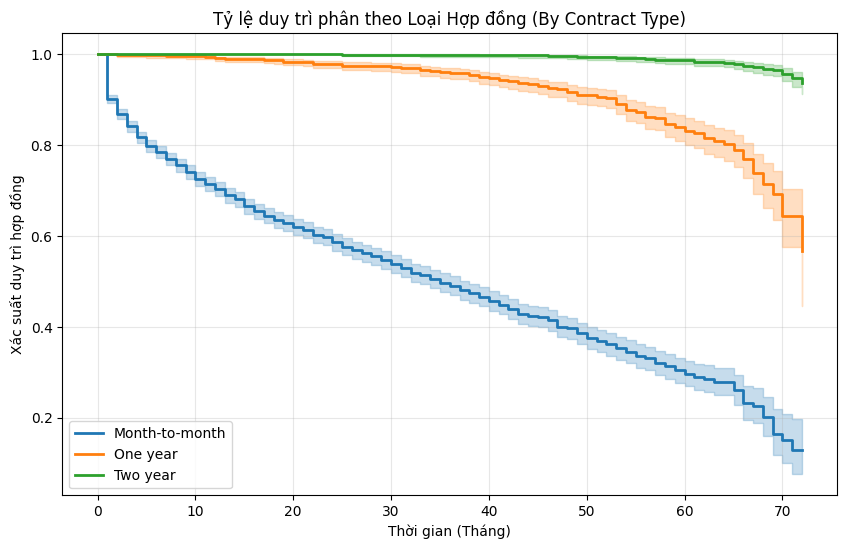

In [37]:
plt.figure(figsize=(10, 6))
ax = plt.subplot(111)

# Lặp qua từng loại hợp đồng để vẽ đường cong riêng
for name, grouped_df in df.groupby('Contract'):
    kmf.fit(grouped_df['tenure'], grouped_df['Churn'], label=name)
    kmf.plot_survival_function(ax=ax, linewidth=2)

plt.title('Tỷ lệ duy trì phân theo Loại Hợp đồng (By Contract Type)')
plt.ylabel('Xác suất duy trì hợp đồng')
plt.xlabel('Thời gian (Tháng)')
plt.grid(True, alpha=0.3)
plt.show()

Part 4: Multivariate Risk Modeling & Insight Extraction (Cox Proportional Hazards)

In [43]:
# 1 Lọc các biến đưa vào mô hình
features = [
    'tenure', 'Churn', 'MonthlyCharges', 'TotalCharges', 
    'SeniorCitizen', 'Dependents', 'Contract', 
    'PaymentMethod', 'InternetService', 'TechSupport', 'PaperlessBilling'
]
df_cox = df[features].copy()

# 2 Xử lý các biến phân loại
binary_cols = ['Dependents', 'PaperlessBilling', 'SeniorCitizen'] 

for col in binary_cols:
    df_cox[col] = df_cox[col].apply(lambda x: 1 if str(x).strip().lower() in ['yes', '1', '1.0', 'true'] else 0)

# One-Hot Encoding cho các biến có nhiều hơn 2 lựa chọn 
categorical_cols = ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport']

# tránh đa cộng tuyến
df_cox = pd.get_dummies(df_cox, columns=categorical_cols, drop_first=True, dtype=int)

# 3 Khởi tạo và huấn luyện mô hình Cox
cph = CoxPHFitter(penalizer=0.1) 
cph.fit(df_cox, duration_col='tenure', event_col='Churn')

print("\n--- KẾT QUẢ MÔ HÌNH COX PH ---")
cph.print_summary()


--- KẾT QUẢ MÔ HÌNH COX PH ---


<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'tenure'
                event col = 'Churn'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -14001.15
         time fit was run = 2026-04-15 15:17:08 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                              
MonthlyCharges                         0.00      1.00      0.00            0.00            0.00                1.00                1.00
TotalCharges                          -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
SeniorCitizen                          0.02      1.02      0.05           -0.08            0.11                0.93                1.12
Dependents                            -0.70      0.50      0.06           -0.82           -0.59                0.44                0.56
PaperlessBilling                       0.20      1.22      0.04            0.11            0.29                1.12                1.33
Contract_One year                     -0.74      0.48      0.06           -0.85           -0.62                0.43                0.54
Contract_Two year                     -1.15      0.32      0.07           -1.28           -1.03                0.28                0.36
PaymentMethod_Credit card (automatic) -0.20      0.82      0.06           -0.31           -0.08                0.73                0.92
PaymentMethod_Electronic check         0.41      1.51      0.05            0.32            0.50                1.37                1.65
PaymentMethod_Mailed check             0.25      1.28      0.06            0.13            0.36                1.14                1.43
InternetService_Fiber optic            0.56      1.76      0.05            0.46            0.66                1.59                1.94
InternetService_No                    -0.44      0.64      0.08           -0.59           -0.29                0.55                0.75
TechSupport_No internet service       -0.44      0.64      0.08           -0.59           -0.29                0.55                0.75
TechSupport_Yes                       -0.34      0.71      0.05           -0.44           -0.24                0.65                0.79

                                       cmp to      z      p  -log2(p)
covariate                                                            
MonthlyCharges                           0.00   2.72   0.01      7.26
TotalCharges                             0.00 -32.10 <0.005    748.69
SeniorCitizen                            0.00   0.37   0.71      0.50
Dependents                               0.00 -11.95 <0.005    106.99
PaperlessBilling                         0.00   4.46 <0.005     16.93
Contract_One year                        0.00 -12.82 <0.005    122.53
Contract_Two year                        0.00 -17.74 <0.005    231.38
PaymentMethod_Credit card (automatic)    0.00  -3.41 <0.005     10.59
PaymentMethod_Electronic check           0.00   8.72 <0.005     58.34
PaymentMethod_Mailed check               0.00   4.24 <0.005     15.44
InternetService_Fiber optic              0.00  10.99 <0.005     90.84
InternetService_No                       0.00  -5.79 <0.005     27.08
TechSupport_No internet service          0.00  -5.79 <0.005     27.08
TechSupport_Yes                          0.00  -6.75 <0.005     35.93
---
Concordance = 0.91
Partial AIC = 28030.30
log-likelihood ratio test = 3303.78 on 14 df
-log2(p) of ll-ratio test = inf

Part 5: Model evaluation

In [45]:
# C-index > 0.7 nghĩa là mô hình có Risk Ranking tốt.
print(f"Concordance Index (C-index): {cph.concordance_index_:.3f}")

Concordance Index (C-index): 0.908



Kiểm tra giả định Proportional Hazards:

   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'MonthlyCharges' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'MonthlyCharges' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'MonthlyCharges' using pd.cut, and then specify it in
`strata=['MonthlyCharges', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


2. Variable 'TotalCharges' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'TotalCharges' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrec

[[<Axes: xlabel='rank-transformed time\n(p=0.0000)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0000)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0150)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0000)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5823)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6814)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0029)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0005)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2999)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4494)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0013)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0000)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0000)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0000)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0950)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1372)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9739)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8091)'>],
 [<Axes: xlabel='rank-transformed tim

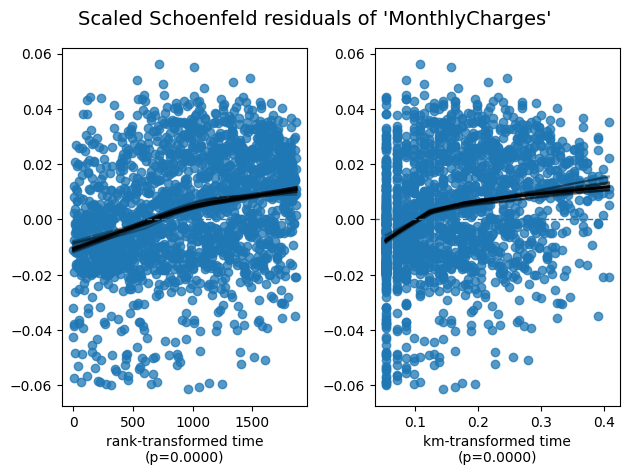

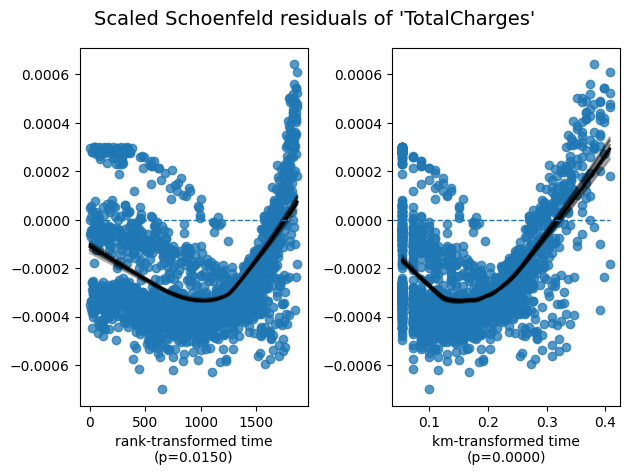

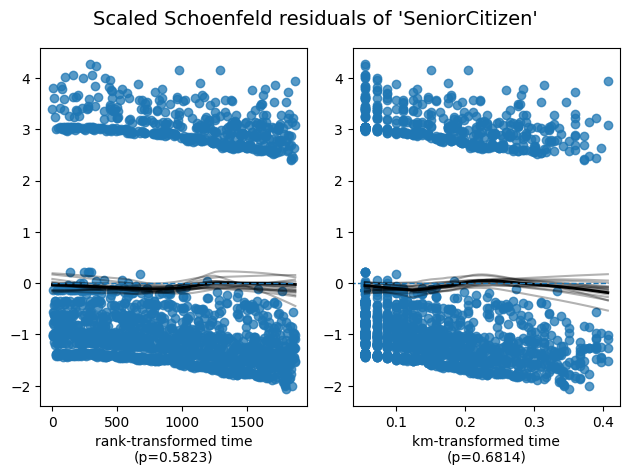

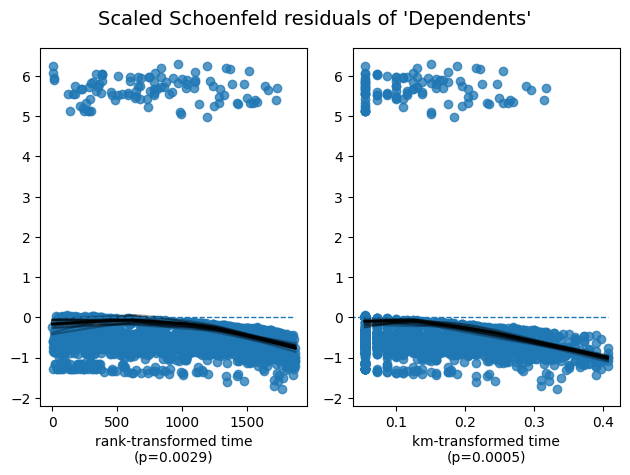

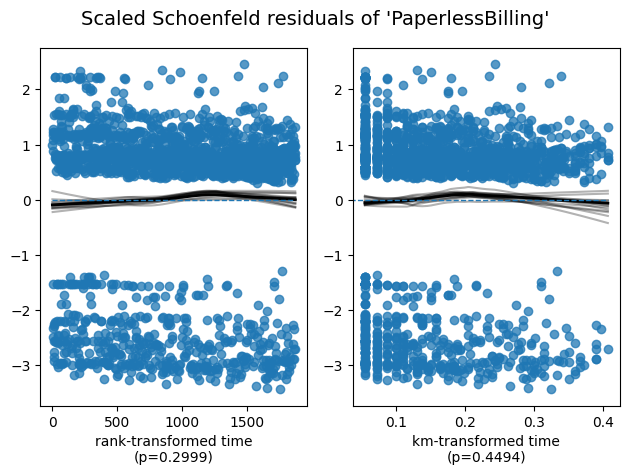

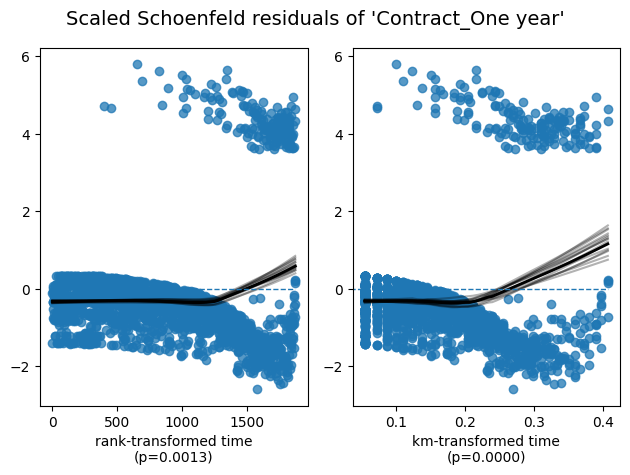

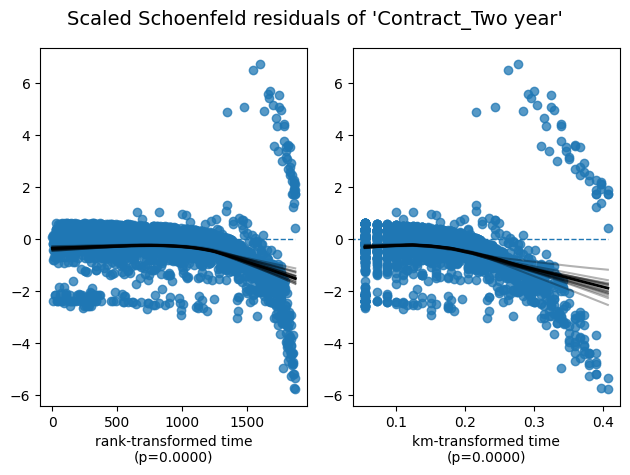

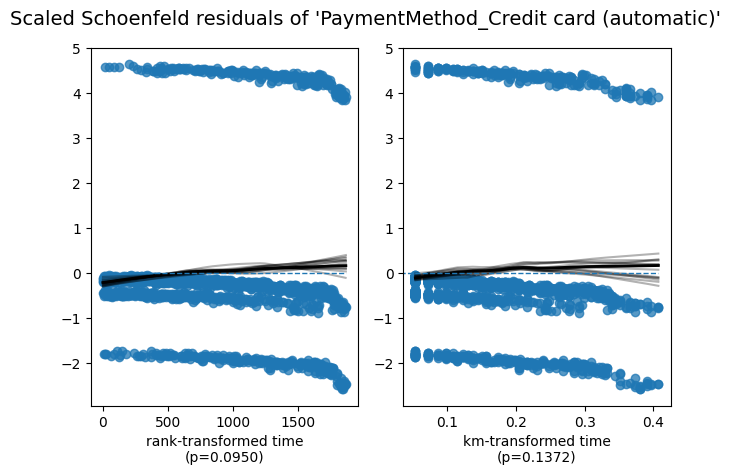

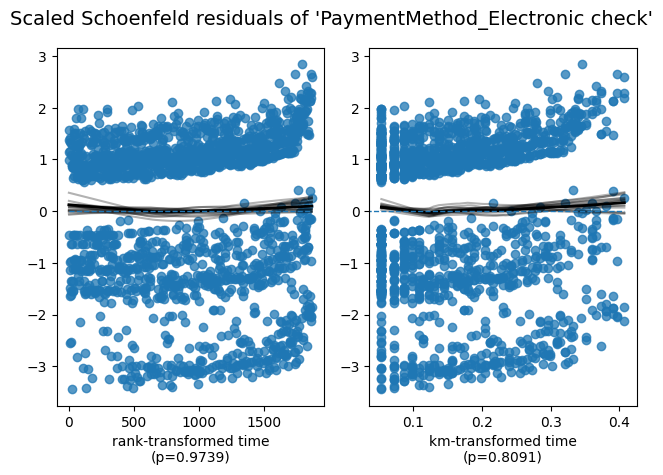

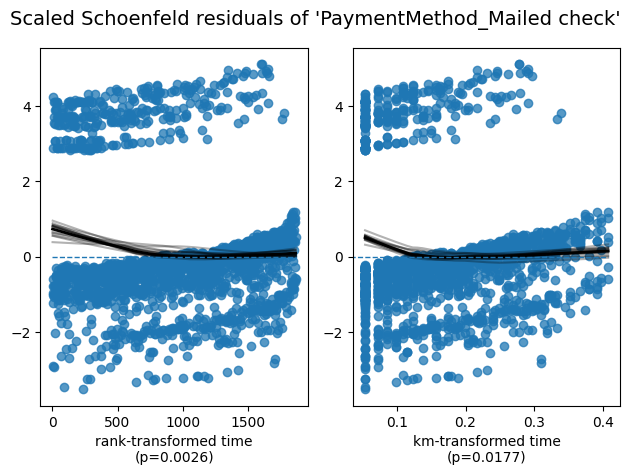

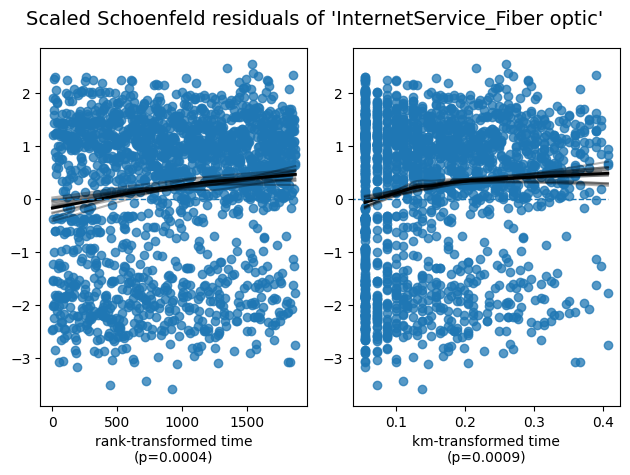

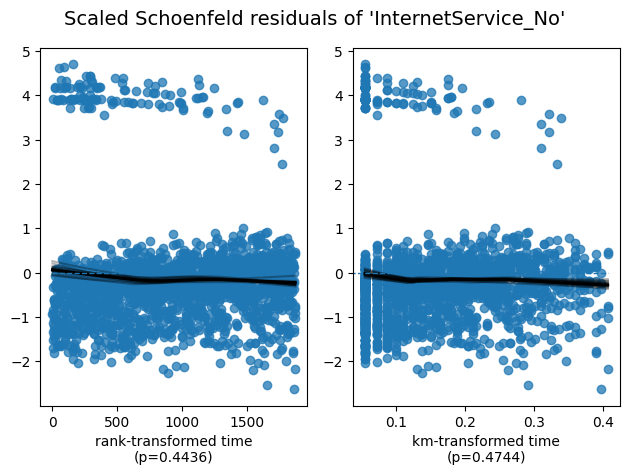

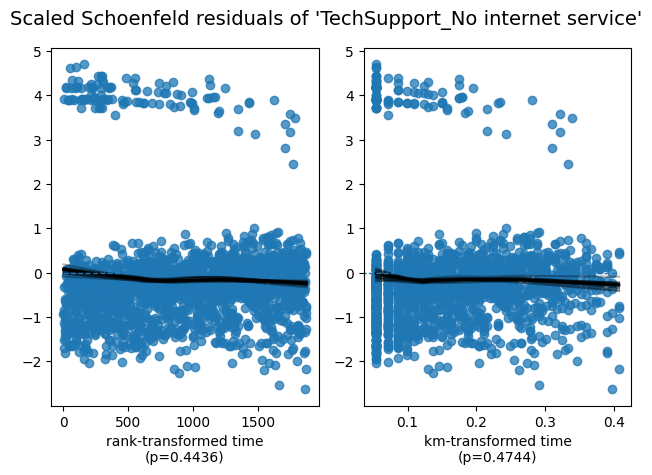

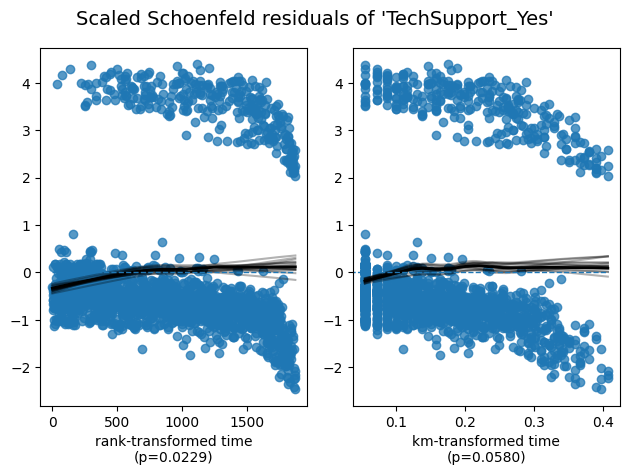

In [46]:
# Insight: Mô hình Cox giả định rằng tỷ lệ rủi ro giữa 2 nhóm phải giữ tỷ lệ không đổi xuyên suốt thời gian. 
print("\nKiểm tra giả định Proportional Hazards:")
cph.check_assumptions(df_cox, p_value_threshold=0.05, show_plots=True)
# Trong dữ liệu thực tế, việc vi phạm một phần giả định này là bình thường.

Part 7: Individual Prediction

C:\Users\Admin\AppData\Local\Temp\ipykernel_12592\522776814.py:8: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  survival_curves.plot(linewidth=2)


<Figure size 1000x600 with 0 Axes>

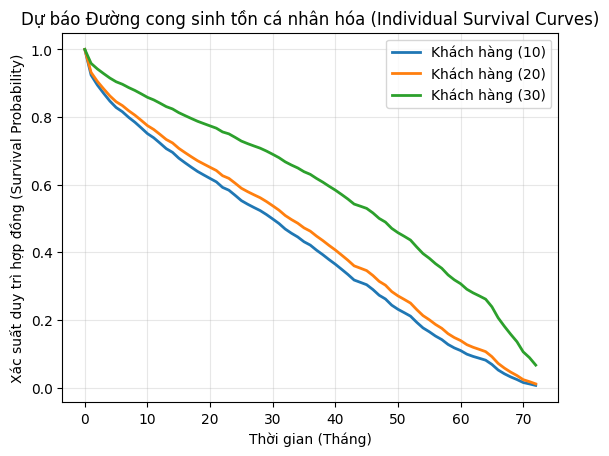

In [47]:
customers_to_predict = df_cox.iloc[[10, 20, 30]]

# Gọi hàm dự báo sinh tồn
survival_curves = cph.predict_survival_function(customers_to_predict)

# Trực quan hóa kết quả dự báo
plt.figure(figsize=(10, 6))
survival_curves.plot(linewidth=2)
plt.title('Dự báo Đường cong sinh tồn cá nhân hóa (Individual Survival Curves)')
plt.ylabel('Xác suất duy trì hợp đồng (Survival Probability)')
plt.xlabel('Thời gian (Tháng)')
plt.grid(True, alpha=0.3)
plt.legend(['Khách hàng (10)', 'Khách hàng (20)', 'Khách hàng (30)'])
plt.show()